# Day 5 Gardner Grading

In [18]:
# Cell 7: Download and unzip the Day 5 Gardner dataset
import requests, zipfile, io, os
from tqdm import tqdm

# URL from the link you provided
data_url = "https://figshare.com/ndownloader/files/39348899"
# Path to save
zip_path = "Blastocyst_dataset.zip"
data_dir_gardner = "dataset/gardner_dataset"


In [19]:
# # Download the file
# print("Downloading Gardner dataset...")
# r = requests.get(data_url, stream=True)
# with open(zip_path, 'wb') as f:
#     for chunk in tqdm(r.iter_content(chunk_size=1024*1024), unit='MB'):
#         if chunk:
#             f.write(chunk)

# # Unzip the file
# print("Unzipping...")
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(data_dir_gardner)
# print(f"Data extracted to {data_dir_gardner}")

# # Clean up the zip file
# os.remove(zip_path)

In [20]:
import os, random, math, time, gc
import numpy as np
import pandas as pd
from PIL import Image

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight


In [21]:
# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Small helpers
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Device: cuda


In [22]:
# paths and basic config
IMG_SIZE = 224
DATA_DIR = "dataset/gardner_dataset"   # expects Images/ + CSV/XLSX from the paper
TRAIN_CSV = os.path.join(DATA_DIR, "Gardner_train_silver.csv")  # separator=';'
TEST_XLSX = os.path.join(DATA_DIR, "Gardner_test_gold.xlsx")    # sheet=Sheet1
IMAGES_DIR = os.path.join(DATA_DIR, "Images")

BATCH = 32
EPOCHS = 60
INIT_LR = 1e-4
WD = 1e-3
PATIENCE = 10  # early stop on macro-F1 across heads
VAL_SIZE = 0.2

# Dynamic loss weight schedule
ADJUST_EVERY = 1       # epochs between reweighting
MIN_F1 = 1e-4          # clamp to avoid div-by-zero
SMOOTH_ALPHA = 0.5     # EMA smoothing for weights across epochs

In [23]:
# Load & preprocess SILVER training set
# - Filter invalid/ND classes (ICM/TE: 0=A,1=B,2=C valid; EXP: 0..5 valid)
# - Build stratification key and remove singleton strata to enable safe stratified split

df_train = pd.read_csv(TRAIN_CSV, sep=';')
print("Train(silver) original rows:", len(df_train))

# Filter: keep valid label ranges
df_train = df_train[df_train["ICM_silver"] < 3]
df_train = df_train[df_train["TE_silver"] < 3]
df_train = df_train[df_train["EXP_silver"] < 6]

# Labels
df_train["expansion_label"] = df_train["EXP_silver"].astype(int)
df_train["icm_label"] = df_train["ICM_silver"].astype(int)
df_train["te_label"]  = df_train["TE_silver"].astype(int)

# Image paths
df_train["path"] = df_train["Image"].apply(lambda x: os.path.join(IMAGES_DIR, x))

# Stratification key (EXP_ICM_TE)
df_train["strat"] = (
    df_train["expansion_label"].astype(str) + "_" +
    df_train["icm_label"].astype(str) + "_" +
    df_train["te_label"].astype(str)
)

# Remove singleton strata to allow stratified split
vc = df_train["strat"].value_counts()
safe_strata = vc[vc >= 2].index
df_train = df_train[df_train["strat"].isin(safe_strata)].reset_index(drop=True)

print("Train(silver) valid rows:", len(df_train))

Train(silver) original rows: 2044
Train(silver) valid rows: 1651


In [24]:
# Train/Val split (stratified on EXP/ICM/TE combo)
tr_df, va_df = train_test_split(
    df_train, test_size=VAL_SIZE, stratify=df_train["strat"], random_state=SEED
)

print("Train rows:", len(tr_df), "| Val rows:", len(va_df))

Train rows: 1320 | Val rows: 331


In [25]:
# Augmentations

train_tfms = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.1, rotate_limit=20, border_mode=0, p=0.85),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.6),
    A.HueSaturationValue(5, 10, 10, p=0.4),
    A.CoarseDropout(max_holes=6, max_height=int(IMG_SIZE*0.08), max_width=int(IMG_SIZE*0.08), p=0.4),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

c:\Users\USER\anaconda3\envs\david\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_2944\3296053933.py:8: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=int(IMG_SIZE*0.08), max_width=int(IMG_SIZE*0.08), p=0.4),


In [26]:
# Focal Loss with optional class weights
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        """
        alpha: torch.Tensor of shape [num_classes] or scalar for weighting
        gamma: focusing parameter (default 2)
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


In [27]:
# Dataset
class GardnerDataset(Dataset):
    def __init__(self, df, augment=None):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row["path"]).convert("RGB"))
        if self.augment is not None:
            img = self.augment(image=img)["image"]
        # labels per head
        lab_exp = torch.tensor(row["expansion_label"], dtype=torch.long)
        lab_icm = torch.tensor(row["icm_label"], dtype=torch.long)
        lab_te  = torch.tensor(row["te_label"],  dtype=torch.long)
        return img, (lab_exp, lab_icm, lab_te)


In [28]:
USE_OVERSAMPLING = False  # toggle here

if USE_OVERSAMPLING:
    # Oversample based on combined label (EXP+ICM+TE) to emphasize rare strata
    labels_combo = tr_df["expansion_label"].astype(str) + "_" + tr_df["icm_label"].astype(str) + "_" + tr_df["te_label"].astype(str)
    class_counts = labels_combo.value_counts()
    weights_per_class = 1.0 / class_counts
    sample_weights = labels_combo.map(weights_per_class).values
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    dl_tr = DataLoader(GardnerDataset(tr_df, augment=train_tfms), batch_size=BATCH, sampler=sampler,
                       num_workers=0, pin_memory=True)
else:
    dl_tr = DataLoader(GardnerDataset(tr_df, augment=train_tfms), batch_size=BATCH, shuffle=True,
                       num_workers=0, pin_memory=True)

dl_va = DataLoader(GardnerDataset(va_df, augment=val_tfms), batch_size=BATCH, shuffle=False,
                   num_workers=0, pin_memory=True)


In [29]:

# Model (EfficientNet-B0 backbone + 3 heads)
class GardnerEffNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.head_exp = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 6))
        self.head_icm = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 3))
        self.head_te  = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 3))

    def forward(self, x):
        feats = self.backbone(x)
        out_exp = self.head_exp(feats)
        out_icm = self.head_icm(feats)
        out_te  = self.head_te(feats)
        return out_exp, out_icm, out_te

model = GardnerEffNet().to(device)

In [30]:
USE_FOCAL = False  # toggle here: False = CrossEntropy, True = FocalLoss

def make_class_weighted_loss(y, num_classes, use_focal=False):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    full_weights = np.zeros(num_classes, dtype=np.float32)
    for cls, w in zip(classes, weights):
        full_weights[int(cls)] = w
    weights_t = torch.tensor(full_weights, dtype=torch.float, device=device)

    if use_focal:
        return FocalLoss(alpha=weights_t, gamma=2.0)
    else:
        return nn.CrossEntropyLoss(weight=weights_t)

ce_exp = make_class_weighted_loss(tr_df["expansion_label"].values, 6, use_focal=USE_FOCAL)
ce_icm = make_class_weighted_loss(tr_df["icm_label"].values,       3, use_focal=USE_FOCAL)
ce_te  = make_class_weighted_loss(tr_df["te_label"].values,        3, use_focal=USE_FOCAL)


In [31]:
# Optimizer & scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=INIT_LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=6, T_mult=2, eta_min=1e-6)

In [32]:
# Validation/Eval utilities (paper-aligned reporting: weighted F1)
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys_exp, ps_exp = [], []
    ys_icm, ps_icm = [], []
    ys_te,  ps_te  = [], []

    for imgs, (lab_exp, lab_icm, lab_te) in loader:
        imgs = imgs.to(device)
        lab_exp = lab_exp.to(device); lab_icm = lab_icm.to(device); lab_te = lab_te.to(device)

        le, li, lt = model(imgs)
        pe = le.argmax(1); pi = li.argmax(1); pt = lt.argmax(1)

        ys_exp.append(lab_exp.cpu().numpy()); ps_exp.append(pe.cpu().numpy())
        ys_icm.append(lab_icm.cpu().numpy()); ps_icm.append(pi.cpu().numpy())
        ys_te.append(lab_te.cpu().numpy());   ps_te.append(pt.cpu().numpy())

    y_exp = np.concatenate(ys_exp); p_exp = np.concatenate(ps_exp)
    y_icm = np.concatenate(ys_icm); p_icm = np.concatenate(ps_icm)
    y_te  = np.concatenate(ys_te);  p_te  = np.concatenate(ps_te)

    # weighted averages (paper style)
    f1_exp = f1_score(y_exp, p_exp, average="weighted")
    f1_icm = f1_score(y_icm, p_icm, average="weighted")
    f1_te  = f1_score(y_te,  p_te,  average="weighted")

    return {
        "y": (y_exp, y_icm, y_te),
        "p": (p_exp, p_icm, p_te),
        "f1": (f1_exp, f1_icm, f1_te)
    }

def print_reports(y_tuple, p_tuple):
    y_exp, y_icm, y_te = y_tuple
    p_exp, p_icm, p_te = p_tuple
    print("\n--- Expansion (0..5) ---")
    print(classification_report(y_exp, p_exp, labels=[0,1,2,3,4,5], target_names=[str(i) for i in range(6)],
                                digits=4, zero_division=0))
    print("\n--- ICM (A=0, B=1, C=2) ---")
    print(classification_report(y_icm, p_icm, labels=[0,1,2], target_names=["A(0)","B(1)","C(2)"],
                                digits=4, zero_division=0))
    print("\n--- TE (A=0, B=1, C=2) ---")
    print(classification_report(y_te, p_te, labels=[0,1,2], target_names=["A(0)","B(1)","C(2)"],
                                digits=4, zero_division=0))



In [33]:
# Dynamic loss weighting across heads (inverse validation F1 with EMA smoothing)
def update_loss_weights(prev_weights, f1s):
    f1e, f1i, f1t = f1s
    f1e = max(f1e, MIN_F1); f1i = max(f1i, MIN_F1); f1t = max(f1t, MIN_F1)
    inv = np.array([1.0/f1e, 1.0/f1i, 1.0/f1t], dtype=np.float64)
    inv = inv / inv.sum()
    new_w = torch.tensor(inv, dtype=torch.float, device=device)
    if prev_weights is None:
        return new_w
    # EMA smoothing to avoid oscillation
    return SMOOTH_ALPHA * new_w + (1.0 - SMOOTH_ALPHA) * prev_weights

In [34]:
# Train / Validate loop (early stopping on macro-weighted F1 across heads)
best_macro_f1 = -1.0
no_improve = 0
loss_weights = None   # [w_exp, w_icm, w_te], set after first val
best_state = None

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss = 0.0
    # per-head running
    run_exp, run_icm, run_te = 0.0, 0.0, 0.0
    n_samples = 0

    pbar = tqdm(dl_tr, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for imgs, (lab_exp, lab_icm, lab_te) in pbar:
        imgs = imgs.to(device, non_blocking=True)
        lab_exp = lab_exp.to(device); lab_icm = lab_icm.to(device); lab_te = lab_te.to(device)

        optimizer.zero_grad()
        out_exp, out_icm, out_te = model(imgs)

        L_exp = ce_exp(out_exp, lab_exp)
        L_icm = ce_icm(out_icm, lab_icm)
        L_te  = ce_te(out_te,   lab_te)

        # If weights not initialized yet, treat as equal
        if loss_weights is None:
            w_exp, w_icm, w_te = 1.0, 1.0, 1.0
        else:
            w_exp, w_icm, w_te = loss_weights.tolist()

        loss = w_exp * L_exp + w_icm * L_icm + w_te * L_te
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        tr_loss += loss.item() * bs
        run_exp += L_exp.item() * bs
        run_icm += L_icm.item() * bs
        run_te  += L_te.item()  * bs
        n_samples += bs

        pbar.set_postfix({
            "loss": f"{tr_loss/n_samples:.4f}",
            "lexp": f"{run_exp/n_samples:.4f}",
            "licm": f"{run_icm/n_samples:.4f}",
            "lte":  f"{run_te/n_samples:.4f}"
        })

    # Validation
    val_metrics = evaluate(model, dl_va)
    f1e, f1i, f1t = val_metrics["f1"]
    macro_f1 = (f1e + f1i + f1t) / 3.0

    # Dynamic reweighting
    if (epoch % ADJUST_EVERY) == 0:
        loss_weights = update_loss_weights(loss_weights, (f1e, f1i, f1t))

    # Scheduler step (use val-driven step for stability)
    scheduler.step(epoch + 0.0)

    # Logs
    print(f"\nEpoch {epoch:02d} | TrainLoss {tr_loss/n_samples:.4f} | ValF1 EXP {f1e:.4f} ICM {f1i:.4f} TE {f1t:.4f} | MacroF1 {macro_f1:.4f}")
    if loss_weights is not None:
        lw = loss_weights.tolist()
        print(f"Current loss weights -> EXP {lw[0]:.3f}, ICM {lw[1]:.3f}, TE {lw[2]:.3f}")

    # Early stopping on macro F1
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_state = { "model": model.state_dict(),
                       "opt": optimizer.state_dict(),
                       "weights": loss_weights,
                       "epoch": epoch,
                       "val_f1": (f1e, f1i, f1t) }
        torch.save(best_state, "best_gardner_multitask.pth")
        no_improve = 0
        print(f"✓ New best macro-F1: {best_macro_f1:.4f} (model saved)")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping (no improvement in {PATIENCE} epochs). Best macro-F1 = {best_macro_f1:.4f}")
            break




Epoch 01 | TrainLoss 3.7313 | ValF1 EXP 0.5940 ICM 0.7278 TE 0.5546 | MacroF1 0.6255
Current loss weights -> EXP 0.346, ICM 0.283, TE 0.371
✓ New best macro-F1: 0.6255 (model saved)



Epoch 02 | TrainLoss 1.0689 | ValF1 EXP 0.6043 ICM 0.7402 TE 0.5679 | MacroF1 0.6375
Current loss weights -> EXP 0.347, ICM 0.283, TE 0.370
✓ New best macro-F1: 0.6375 (model saved)



Epoch 03 | TrainLoss 1.0024 | ValF1 EXP 0.5917 ICM 0.7446 TE 0.6015 | MacroF1 0.6459
Current loss weights -> EXP 0.353, ICM 0.285, TE 0.362
✓ New best macro-F1: 0.6459 (model saved)



Epoch 04 | TrainLoss 0.9510 | ValF1 EXP 0.5760 ICM 0.7117 TE 0.6019 | MacroF1 0.6299
Current loss weights -> EXP 0.357, ICM 0.289, TE 0.354



Epoch 05 | TrainLoss 0.9251 | ValF1 EXP 0.6004 ICM 0.7164 TE 0.6129 | MacroF1 0.6432
Current loss weights -> EXP 0.356, ICM 0.293, TE 0.351


...


Epoch 52 | TrainLoss 0.1444 | ValF1 EXP 0.7431 ICM 0.7995 TE 0.7231 | MacroF1 0.7552
Current loss weights -> EXP 0.335, ICM 0.318, TE 0.348



Epoch 53 | TrainLoss 0.1330 | ValF1 EXP 0.7648 ICM 0.7828 TE 0.7336 | MacroF1 0.7604
Current loss weights -> EXP 0.333, ICM 0.321, TE 0.347



Epoch 54 | TrainLoss 0.1170 | ValF1 EXP 0.7584 ICM 0.7993 TE 0.7433 | MacroF1 0.7670
Current loss weights -> EXP 0.335, ICM 0.320, TE 0.345



Epoch 55 | TrainLoss 0.1076 | ValF1 EXP 0.7565 ICM 0.7963 TE 0.7194 | MacroF1 0.7574
Current loss weights -> EXP 0.334, ICM 0.318, TE 0.348



Epoch 56 | TrainLoss 0.1111 | ValF1 EXP 0.7549 ICM 0.7996 TE 0.6838 | MacroF1 0.7461
Current loss weights -> EXP 0.331, ICM 0.314, TE 0.355
Early stopping (no improvement in 10 epochs). Best macro-F1 = 0.7710


In [35]:
# Load best and evaluate on validation once more (final report on val)
ckpt = torch.load("best_gardner_multitask.pth", map_location=device)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint @ epoch {ckpt['epoch']} with ValF1 (EXP,ICM,TE) = {ckpt['val_f1']} and weights {ckpt['weights']}")

val_metrics = evaluate(model, dl_va)
print_reports(val_metrics["y"], val_metrics["p"])

Loaded best checkpoint @ epoch 46 with ValF1 (EXP,ICM,TE) = (0.7667873176605182, 0.8136735576660061, 0.73267777680059) and weights tensor([0.3348, 0.3158, 0.3494], device='cuda:0')

--- Expansion (0..5) ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0000    0.0000    0.0000         0
           2     0.6636    0.8353    0.7396        85
           3     0.8657    0.7982    0.8305       218
           4     0.3913    0.3214    0.3529        28
           5     0.0000    0.0000    0.0000         0

    accuracy                         0.7674       331
   macro avg     0.3201    0.3258    0.3205       331
weighted avg     0.7736    0.7674    0.7668       331


--- ICM (A=0, B=1, C=2) ---
              precision    recall  f1-score   support

        A(0)     0.8889    0.8855    0.8872       262
        B(1)     0.5429    0.5758    0.5588        66
        C(2)     0.0000    0.0000    0.0000         3

   

In [39]:
# GOLD test set evaluation (paper-style)
df_test = pd.read_excel(TEST_XLSX, sheet_name="Sheet1")
print("Gold test original rows:", len(df_test))

# robust cleaning: coerce + drop NAs
for col in ["EXP_gold", "ICM_gold", "TE_gold"]:
    df_test[col] = pd.to_numeric(df_test[col], errors="coerce")
df_test = df_test.dropna(subset=["EXP_gold","ICM_gold","TE_gold"]).reset_index(drop=True)

# cast & filter to valid ranges (EXP 0..5, ICM/TE 0..2)
df_test["expansion_label"] = df_test["EXP_gold"].astype(int)
df_test["icm_label"]       = df_test["ICM_gold"].astype(int)
df_test["te_label"]        = df_test["TE_gold"].astype(int)

df_test = df_test[(df_test["expansion_label"] < 6) & (df_test["icm_label"] < 3) & (df_test["te_label"] < 3)].reset_index(drop=True)
df_test["path"] = df_test["Image"].apply(lambda x: os.path.join(IMAGES_DIR, x))

print("Gold test valid rows:", len(df_test))

ds_te = GardnerDataset(df_test, augment=val_tfms)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
with torch.no_grad():
    test_metrics = evaluate(model, dl_te)
print("\n=== GOLD TEST SET REPORTS (paper-aligned) ===")
print_reports(test_metrics["y"], test_metrics["p"])

f1e, f1i, f1t = test_metrics["f1"]
print(f"Gold Test Weighted F1 -> EXP {f1e:.4f} | ICM {f1i:.4f} | TE {f1t:.4f} | Macro {((f1e+f1i+f1t)/3):.4f}")

Gold test original rows: 300
Gold test valid rows: 225

=== GOLD TEST SET REPORTS (paper-aligned) ===

--- Expansion (0..5) ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0000    0.0000    0.0000         0
           2     0.8630    0.7412    0.7975        85
           3     0.8357    0.8667    0.8509       135
           4     0.1667    0.4000    0.2353         5
           5     0.0000    0.0000    0.0000         0

    accuracy                         0.8089       225
   macro avg     0.3109    0.3346    0.3139       225
weighted avg     0.8312    0.8089    0.8170       225


--- ICM (A=0, B=1, C=2) ---
              precision    recall  f1-score   support

        A(0)     0.7263    0.9028    0.8050       144
        B(1)     0.5111    0.3538    0.4182        65
        C(2)     0.0000    0.0000    0.0000        16

    accuracy                         0.6800       225
   macro avg     0.4125    0

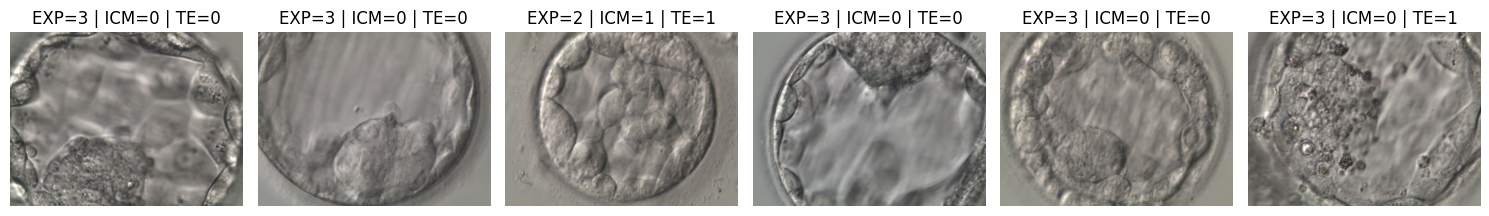

In [40]:
import matplotlib.pyplot as plt

def show_samples(df, n=6):
    """Plot n random samples with EXP, ICM, TE labels."""
    sample_df = df.sample(n=n).reset_index(drop=True)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))

    for i, ax in enumerate(axes):
        row = sample_df.iloc[i]
        img = np.array(Image.open(row["path"]).convert("RGB"))
        ax.imshow(img)
        ax.set_title(f"EXP={row['expansion_label']} | ICM={row['icm_label']} | TE={row['te_label']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example: show samples from validation set
show_samples(va_df, n=6)


Predicted Grades:
  Expansion: 4 (class 3)
  ICM: A (class 0)
  TE: A (class 0)

Ground Truth Grades:
  Expansion: 4
  ICM: A
  TE: A


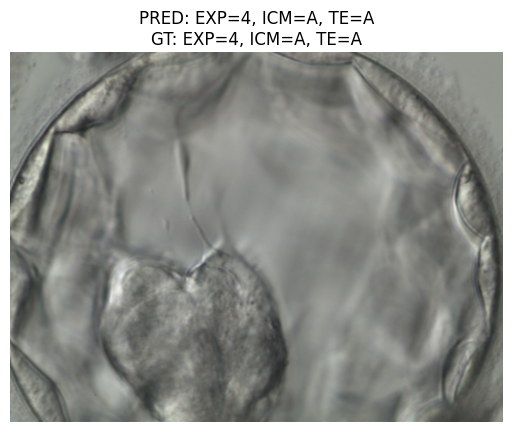

In [41]:
def predict_single_image(model, img_path, df_ref=None, transform=val_tfms, device=device):
    """
    Predict Gardner grades for a single embryo image.
    If df_ref is provided, will also show ground truth labels.
    """
    model.eval()
    img = np.array(Image.open(img_path).convert("RGB"))
    img_tensor = transform(image=img)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        out_exp, out_icm, out_te = model(img_tensor)
        pred_exp = out_exp.argmax(1).item()
        pred_icm = out_icm.argmax(1).item()
        pred_te  = out_te.argmax(1).item()

    # Map to human-readable grades
    exp_labels = ["1","2","3","4","5","6"]  # Gardner EXP scale
    icm_labels = ["A","B","C"]
    te_labels  = ["A","B","C"]

    # Ground truth lookup (if test dataframe provided)
    if df_ref is not None:
        row = df_ref[df_ref["path"] == img_path]
        if not row.empty:
            gt_exp = exp_labels[int(row["expansion_label"].values[0])]
            gt_icm = icm_labels[int(row["icm_label"].values[0])]
            gt_te  = te_labels[int(row["te_label"].values[0])]
        else:
            gt_exp, gt_icm, gt_te = None, None, None
    else:
        gt_exp, gt_icm, gt_te = None, None, None

    # Print results
    print(f"Predicted Grades:")
    print(f"  Expansion: {exp_labels[pred_exp]} (class {pred_exp})")
    print(f"  ICM: {icm_labels[pred_icm]} (class {pred_icm})")
    print(f"  TE: {te_labels[pred_te]} (class {pred_te})")

    if gt_exp is not None:
        print("\nGround Truth Grades:")
        print(f"  Expansion: {gt_exp}")
        print(f"  ICM: {gt_icm}")
        print(f"  TE: {gt_te}")

    # Plot image with both
    plt.imshow(img)
    if gt_exp is not None:
        plt.title(f"PRED: EXP={exp_labels[pred_exp]}, ICM={icm_labels[pred_icm]}, TE={te_labels[pred_te]}\n"
                  f"GT: EXP={gt_exp}, ICM={gt_icm}, TE={gt_te}")
    else:
        plt.title(f"PRED: EXP={exp_labels[pred_exp]}, ICM={icm_labels[pred_icm]}, TE={te_labels[pred_te]}")
    plt.axis("off")
    plt.show()

# Pick a test image from gold set
img_path = df_test.iloc[10]["path"]

# Predict and compare against ground truth
predict_single_image(model, img_path, df_ref=df_test)


In [42]:
import sys
sys.exit()

SystemExit: 

c:\Users\USER\anaconda3\envs\david\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
